In [1]:
# 1. IMPORT CÁC THƯ VIỆN CẦN THIẾT
import torch
import matplotlib.pyplot as plt
import os

# Import các module đã refactor trong src/
from src.model import FineTunedModel
from src.utils import load_subset, load_image
from src.analysis import run_complete_analysis, analyze_class_characteristic_atoms, visualize_unique_atoms_grid
from src.atom import visualize_all_unique_atoms, AtomVisualizer

# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# 2. LOAD MODEL VÀ DICTIONARY (D)
model = FineTunedModel(num_classes=10).to(device)
model.load_state_dict(torch.load('weights/finetune_weights.pth', map_location=device))

# Target layer để phân tích (Feature Extractor layer 5)
TARGET_LAYER_IDX = 5
target_layer = model.feature_extractor[TARGET_LAYER_IDX]

# Load Dictionary đã học từ HALS
D = torch.load('weights/hals_nnd_D.pth', map_location=device)
print(f"Model loaded. Dictionary shape: {D.shape}")

Model loaded. Dictionary shape: torch.Size([500, 13, 13])


Loading subset from: data/subset
  cassette_player:  10 images (label=0)
  chain_saw   :  10 images (label=1)
  church      :  10 images (label=2)
  English_springer:  10 images (label=3)
  French_horn :  10 images (label=4)
  garbage_truck:  10 images (label=5)
  gas_pump    :  10 images (label=6)
  golf_ball   :  10 images (label=7)
  parachute   :  10 images (label=8)
  tench       :  10 images (label=9)

Total: 100 images loaded
Using device: cuda

Analyzing 100 images in batches of 10...


/home/tamnt/.conda/envs/xfrt128/lib/python3.10/site-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Processed batch 1/10
Processed batch 2/10
Processed batch 3/10
Processed batch 4/10
Processed batch 5/10
Processed batch 6/10
Processed batch 7/10
Processed batch 8/10
Processed batch 9/10
Processed batch 10/10

Computing similarity matrices...

Saved visualization to: similarity_analysis.png


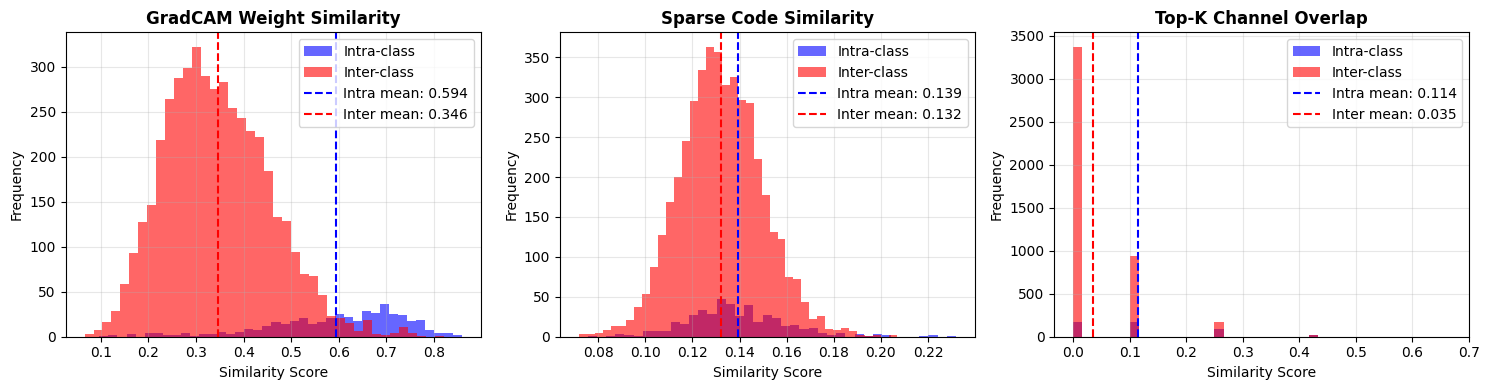

In [3]:
# 3. CHẠY PHÂN TÍCH TOÀN BỘ (SPARSE CODING & THỐNG KÊ)
# Load ảnh từ thư mục data/subset
subset_paths = load_subset(subset_root="data/subset")

# Chạy phân tích (Tính GradCAM, Sparse Codes, Similarity...)
full_analysis = run_complete_analysis(
    model=model,
    target_layer=target_layer,
    D=D,
    subset_paths=subset_paths,
    k=5,          # Top-5 channels quan trọng nhất
    lam=1e-2,     # L1 Regularization
    batch_size=10 # Tùy chỉnh theo GPU memory
)


CLASS-CHARACTERISTIC ATOMS ANALYSIS


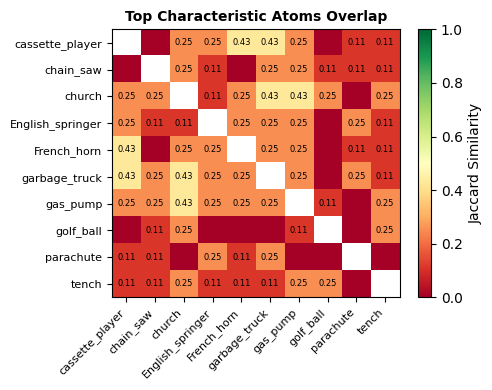

Saved visualization to: figures/unique_atoms_grid.png


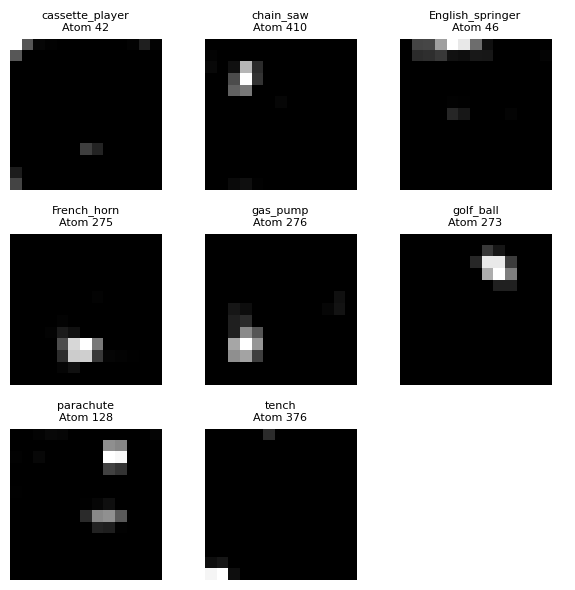

In [4]:
# 4. TÌM CÁC ATOM ĐẶC TRƯNG CHO TỪNG CLASS
atom_analysis = analyze_class_characteristic_atoms(
    results=full_analysis['results'],
    n_atoms=len(D),
    top_k_atoms=10,
    threshold=0.1
)

# Hiển thị grid các unique atoms (dạng heatmap đơn giản)
visualize_unique_atoms_grid(atom_analysis, D)

Bắt đầu tạo Visualization toàn diện cho các Unique Atoms...
Processing Class: cassette_player | Atom: 42


/home/tamnt/.conda/envs/xfrt128/lib/python3.10/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved visualization to figures/comprehensive/class_cassette_player_atom_42.png


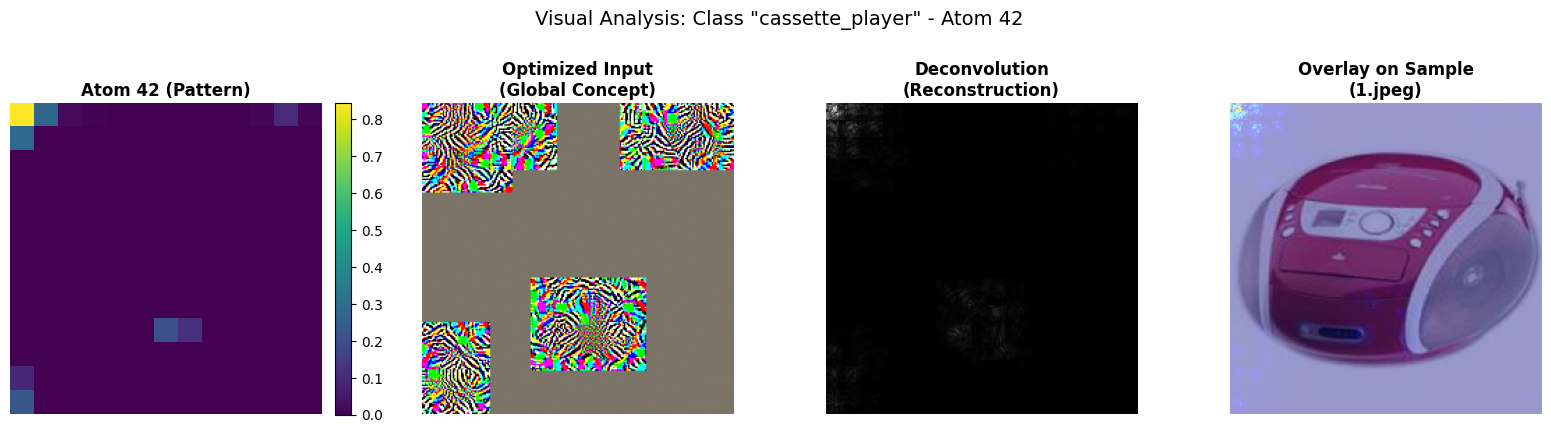

Processing Class: chain_saw | Atom: 410
Saved visualization to figures/comprehensive/class_chain_saw_atom_410.png


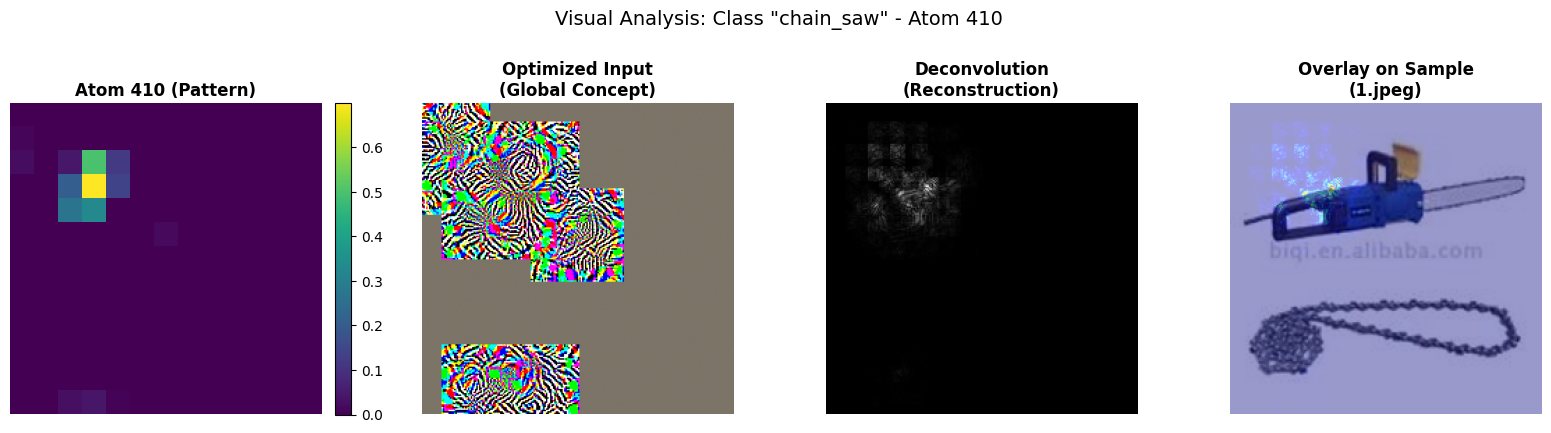

Processing Class: English_springer | Atom: 46
Saved visualization to figures/comprehensive/class_English_springer_atom_46.png


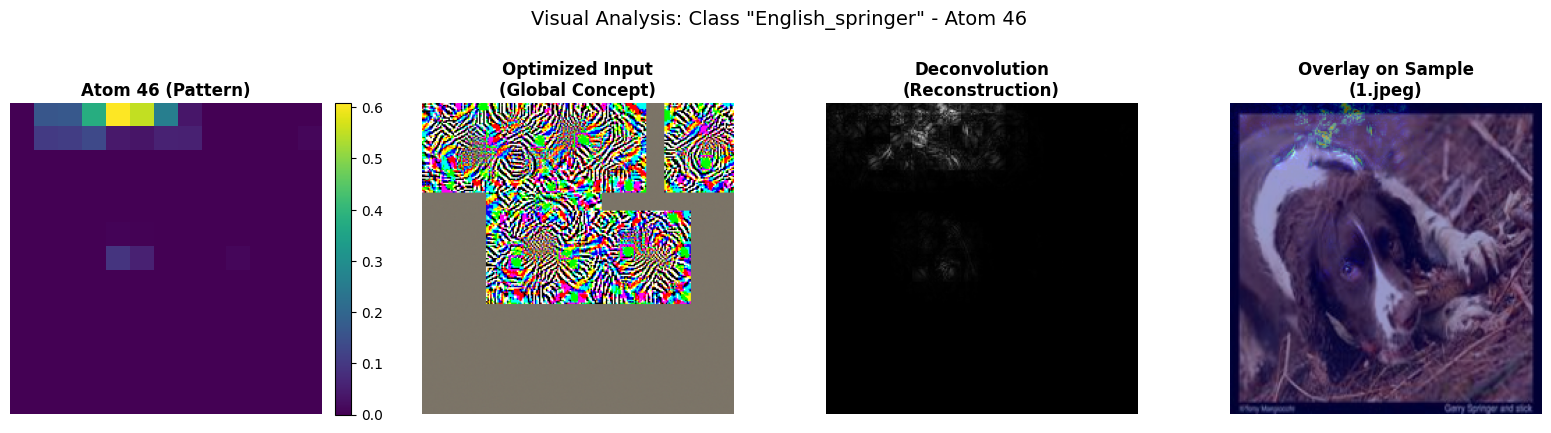

Processing Class: French_horn | Atom: 275
Saved visualization to figures/comprehensive/class_French_horn_atom_275.png


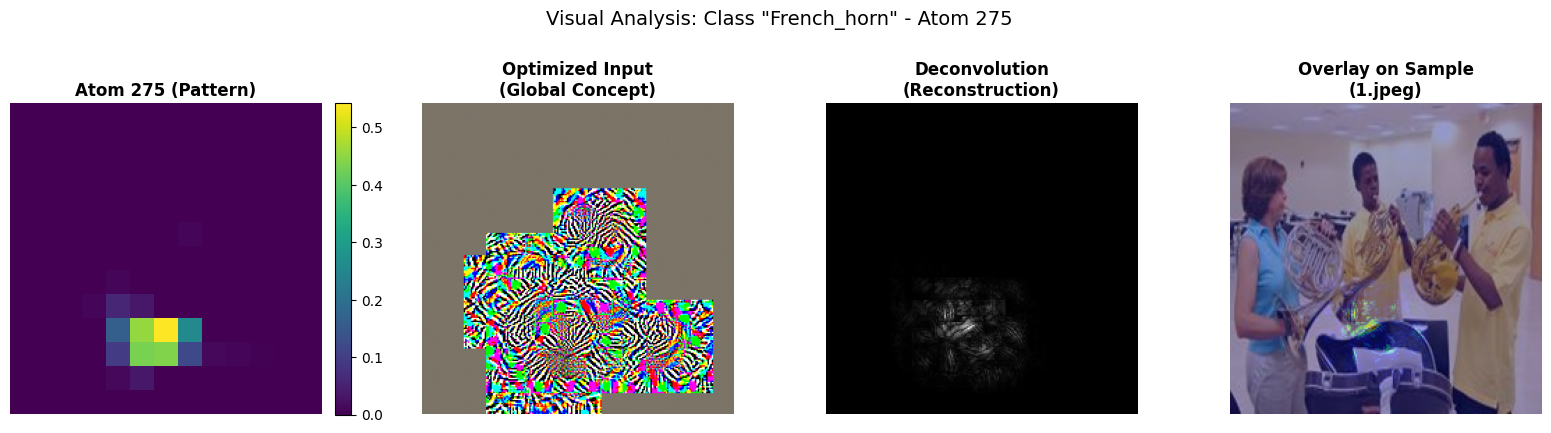

Processing Class: gas_pump | Atom: 276
Saved visualization to figures/comprehensive/class_gas_pump_atom_276.png


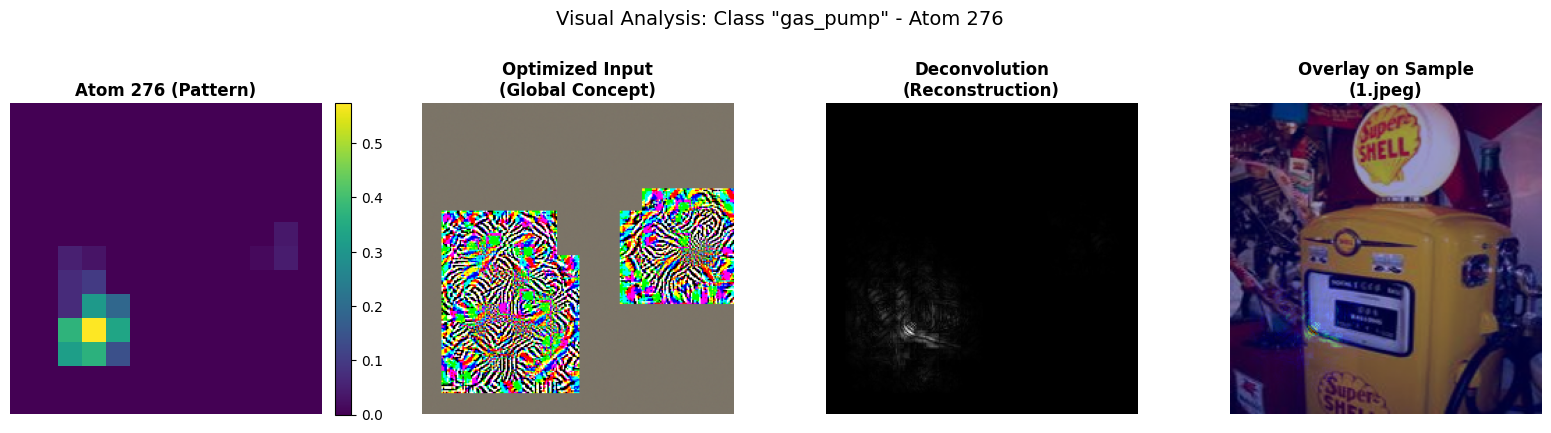

Processing Class: golf_ball | Atom: 273
Saved visualization to figures/comprehensive/class_golf_ball_atom_273.png


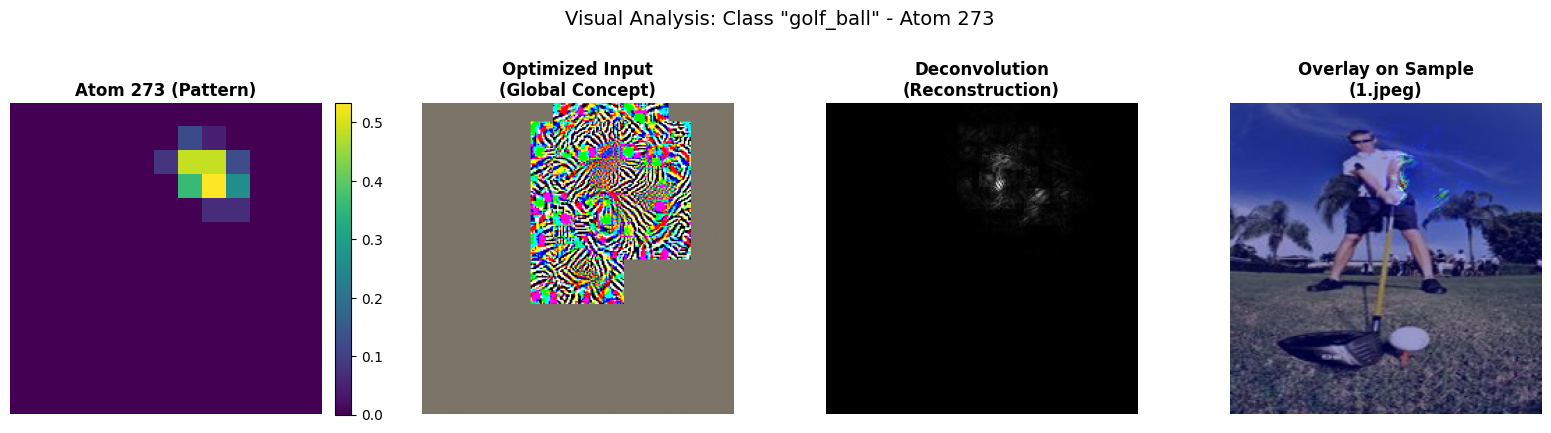

Processing Class: parachute | Atom: 128
Saved visualization to figures/comprehensive/class_parachute_atom_128.png


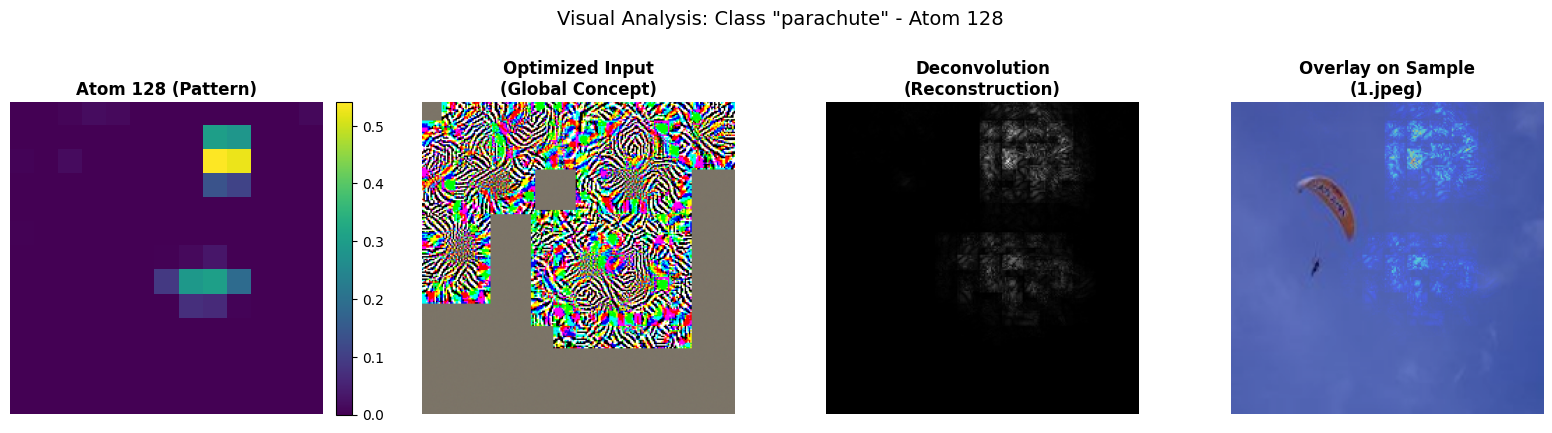

Processing Class: tench | Atom: 376
Saved visualization to figures/comprehensive/class_tench_atom_376.png


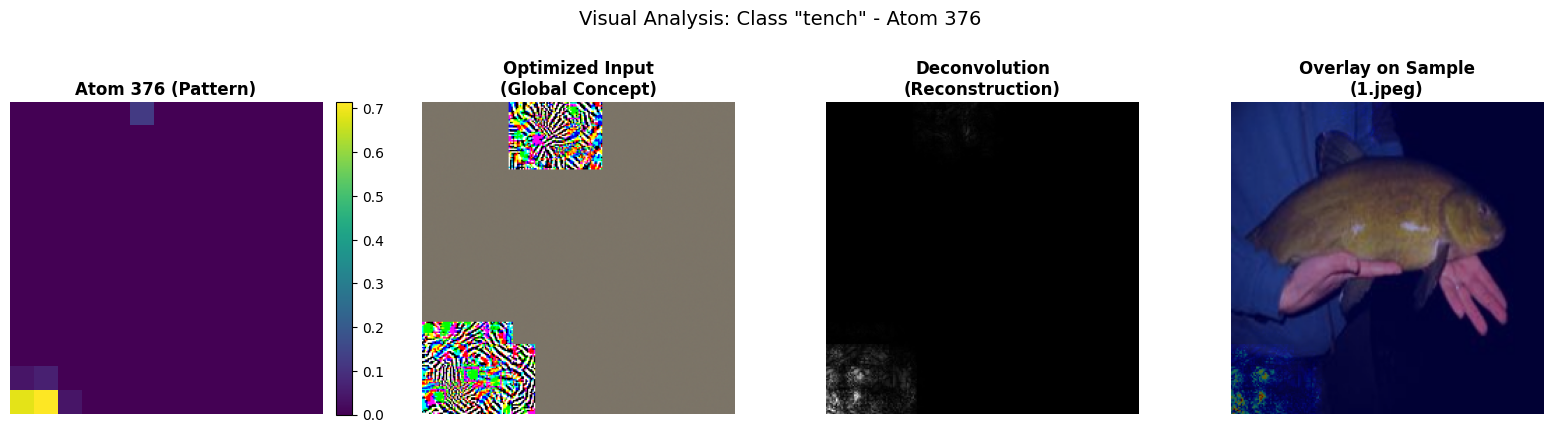

In [5]:
# 5. VISUALIZATION NÂNG CAO (OPTIMIZATION + GUIDED BACKPROP)
# Phần này sẽ vẽ chi tiết: Atom trông như thế nào, nó kích hoạt bởi cái gì, 
# và nó nằm ở đâu trên ảnh thực tế.

print("Bắt đầu tạo Visualization toàn diện cho các Unique Atoms...")
visualize_all_unique_atoms(
    atom_analysis=atom_analysis,
    D=D,
    model=model,
    target_layer_idx=TARGET_LAYER_IDX,
    subset_paths=subset_paths,
    device=device
)